# Linear Regression - Top model according to the SCPM of -5.30

In [1]:
%load_ext nb_black

<IPython.core.display.Javascript object>

In [2]:
# Database Reading and Manipulation
import pandas as pd

# Linear Algebra
import numpy as np

# Plotting
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

# Model Selection
from sklearn.model_selection import train_test_split
from sklearn.model_selection import TimeSeriesSplit
from sklearn.model_selection import RepeatedKFold
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_validate
from sklearn.model_selection import GridSearchCV

# Modeling
from sklearn.linear_model import LinearRegression

# Metrics
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.metrics import r2_score

# Processing
from sklearn.preprocessing import StandardScaler


# Pipeline
from sklearn.pipeline import Pipeline

# Data imputation
from sklearn.impute import SimpleImputer

# Custom modules
## Model selection
from src.cross_validation.blocking_time_series_split import BlockingTimeSeriesSplit

## Function to print scores
from src.utils.print_scores import print_scores

## Function to calculate score regression metrics
from src.utils.score_regression_metrics import score_regression_metrics

## Function to fill the results metric dict
from src.utils.fill_results_dict import fill_results_dict

# Warnings
import warnings

<IPython.core.display.Javascript object>

# Functions and definitions

In [3]:
def get_linreg_df_importances(scores):
    coefs = {}
    bias = {}
    coefs_with_column = []
    columns = x.columns

    for index, pipeline in enumerate(scores["estimator"]):
        model = pipeline.named_steps["estimator"]
        coefs[index] = model.coef_.copy()
        bias[index] = model.intercept_.copy()

    for index, coefs_vec in coefs.items():
        coefs_col = pd.DataFrame(
            {col: [c] for col, c in zip(columns, coefs_vec)},
            index=[f"Coefficients - {index}"],
        )
        coefs_with_column.append(coefs_col)
    df_bias = pd.Series(bias)
    df_coefs = pd.concat(coefs_with_column)

    return df_coefs, df_bias

<IPython.core.display.Javascript object>

In [4]:
SEED = 47
METRICS = (
    "neg_root_mean_squared_error",
    "neg_mean_absolute_error",
    "neg_mean_absolute_percentage_error",
    "r2",
)
METRICS_DICT = {
    "neg_root_mean_squared_error": "RMSE",
    "neg_mean_absolute_error": "MAE",
    "neg_mean_absolute_percentage_error": "MAPE",
    "r2": "R2",
}

<IPython.core.display.Javascript object>

## Defining a dataframe structure to save the results

In [5]:
results_to_save = []

results_dict = {
    "Category": "Local Model",
    "Company": "partner_ii",
    "Features": "Chemical + Mineralogical + CS1 + CS3 + CS7",
    "Data Shape": None,
    "Timesteps": None,
    "Model": "Linear Regression",
    "Model Params": None,
    "Scaler": "Standard Scaler",
    "Scaler Params": None,
    "Imputer": "Median",
    "Imputer Params": None,
    "Cross Validation": None,
    "Cross Validation Params": np.nan,
    "RMSE Train": np.nan,
    "MAE Train": np.nan,
    "MAPE Train": np.nan,
    "R2 Train": np.nan,
    "RMSE Test": np.nan,
    "MAE Test": np.nan,
    "MAPE Test": np.nan,
    "R2 Test": np.nan,
}

<IPython.core.display.Javascript object>

# Reading the dataset

In [6]:
df = pd.read_csv("../../../../data/processed/partner_ii/cement-shipping.csv")

<IPython.core.display.Javascript object>

## Defining Features

In this set of experiments we keep only chemical and mineralogical features yielded by the same testing method/procedure

In [7]:
df_copy = df.drop(
    [
        "Cement_Type",
    ],
    axis=1,
).copy()

<IPython.core.display.Javascript object>

# 1. Linear Regression

<h2>1. Dataset: df_no_cs</h2> <br>In this dataset the CS1, CS3  and CS7 variables are not considered. Only Chemical and mineralogical features measured by the same method. For this particular dataset, all chemical features, with the exception of LOI were measured by XRF and XRD methods.

In [8]:
y = df_copy.pop("CS28").values
x = df_copy.drop(["Date"], axis=1)
dates = df["Date"].copy()

<IPython.core.display.Javascript object>

## 1.2. Blocking Time Series Cross Validation

<b>Dataset shape:</b> (1234, 38)<br>
<b>Splits:</b>5<br>    
    1. 5 folds of 246 samples
    2. 50% train (123 samples each fold)
    3. 50% test (123 samples each fold)
<b>Total:</b> 5 models<br>

In [9]:
repeats = 3
n_splits = 5
train_size = 0.8

pipeline = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="median")),
        ("transformer", StandardScaler()),
        ("estimator", LinearRegression()),
    ]
)
cv = BlockingTimeSeriesSplit(n_splits=n_splits, train_size=train_size)
scores = cross_validate(
    pipeline,
    x,
    y,
    scoring=METRICS,
    cv=cv,
    n_jobs=-1,
    return_train_score=True,
    return_estimator=True,
    return_indices=True,
)
print("Blocking Time Series Split:")
print(f"Repeats: {repeats}")
print(f"n_splits: {n_splits}")
print()
print_scores(scores, METRICS, METRICS_DICT)

results_dict_copy = results_dict.copy()
results_dict_copy["Cross Validation"] = "Blocking Time Series Split"
results_dict_copy[
    "Cross Validation Params"
] = '{"N_Splits": 5, "Repeats": 1, "train_size": 0.8}'
results_dict_copy["Data Shape"] = x.shape
df_results = fill_results_dict(results_dict_copy, scores)
results_to_save.append(df_results)

Blocking Time Series Split:
Repeats: 3
n_splits: 5

******
[TRAIN]
******
RMSE: -1.263 (0.118)
MAE: -0.989 (0.097)
MAPE: -0.023 (0.003)
R2: 0.828 (0.051)


******
[TEST]
******
RMSE: -1.694 (0.274)
MAE: -1.392 (0.263)
MAPE: -0.032 (0.006)
R2: 0.696 (0.111)




<IPython.core.display.Javascript object>

## Plotting the Predictions

In [10]:
df_pred = pd.DataFrame()
df_pred["DATE"] = dates.copy()
df_pred["CS28"] = y.copy()
df_pred["CS28_PRED"] = np.nan
df_pred["SET"] = ""
df_pred["CEMENT_TYPE"] = df["Cement_Type"].copy()
df_pred["DATE"] = pd.to_datetime(df_pred["DATE"])


for idx, pipeline in enumerate(scores["estimator"]):
    index_train = scores["indices"]["train"][idx]
    index_test = scores["indices"]["test"][idx]
    index_preds = np.concatenate([index_train, index_test])

    # results = scores["estimator"][0].predict(x.loc[index_preds])
    results = pipeline.predict(x.loc[index_preds])
    df_pred.loc[index_preds, "CS28_PRED"] = results.copy()
    df_pred.loc[index_train, "SET"] = "TRAIN"
    df_pred.loc[index_test, "SET"] = "TEST"
df_pred = df_pred.dropna()

<IPython.core.display.Javascript object>

In [11]:
df_pred[["DATE", "CS28", "CS28_PRED", "SET"]]

,DATE,CS28,CS28_PRED,SET
0,2020-01-01 11:00:00+00:00,42.93,42.533542,TRAIN
1,2020-01-02 11:00:00+00:00,49.72,47.163708,TRAIN
2,2020-01-02 11:00:00+00:00,39.49,40.620572,TRAIN
3,2020-01-03 11:00:00+00:00,40.55,40.716223,TRAIN
4,2020-01-04 11:00:00+00:00,42.64,42.399342,TRAIN
...,...,...,...,...
1045,2021-12-25 11:00:00+00:00,37.12,39.078727,TEST
1046,2021-12-26 11:00:00+00:00,40.22,39.218182,TEST
1047,2021-12-27 11:00:00+00:00,44.20,44.351082,TEST
1048,2021-12-28 11:00:00+00:00,46.44,45.921567,TEST


<IPython.core.display.Javascript object>

In [12]:
df_copy_copy = df_copy.copy()
df_copy_copy["Date"] = pd.to_datetime(df_copy_copy["Date"])
df_copy_copy["Date"] = df_copy_copy["Date"].dt.tz_localize(None)

df_pred_copy = df_pred.copy()
df_pred_copy["DATE"] = pd.to_datetime(df_pred_copy["DATE"])
df_pred_copy["DATE"] = df_pred_copy["DATE"].dt.tz_localize(None)

df_copy_merge = df_copy_copy.reset_index(drop=True).merge(
    df_pred_copy.reset_index(drop=True), left_index=True, right_index=True, how="inner"
)
df_copy_merge["COMPANY"] = "Partner i"
df_copy_merge["PLANT"] = "Partner i"

for fold, (train_index, test_index) in enumerate(cv.split(x)):
    df_copy_merge.loc[train_index, "FOLD"] = fold + 1
    df_copy_merge.loc[test_index, "FOLD"] = fold + 1
df_copy_merge["FOLD"] = df_copy_merge["FOLD"].astype(int)
df_copy_merge.to_excel("local_model_random_forest_btsscv_partner_i.xlsx", index=False)
df_copy_merge.to_csv("local_model_random_forest_btsscv_partner_i.csv", index=False)

<IPython.core.display.Javascript object>

In [13]:
df_pred

,DATE,CS28,CS28_PRED,SET,CEMENT_TYPE
0,2020-01-01 11:00:00+00:00,42.93,42.533542,TRAIN,Type I-II
1,2020-01-02 11:00:00+00:00,49.72,47.163708,TRAIN,Type III
2,2020-01-02 11:00:00+00:00,39.49,40.620572,TRAIN,Type I-II
3,2020-01-03 11:00:00+00:00,40.55,40.716223,TRAIN,Type I-II
4,2020-01-04 11:00:00+00:00,42.64,42.399342,TRAIN,Type I-II
...,...,...,...,...,...
1045,2021-12-25 11:00:00+00:00,37.12,39.078727,TEST,Type I-II
1046,2021-12-26 11:00:00+00:00,40.22,39.218182,TEST,Type I-II
1047,2021-12-27 11:00:00+00:00,44.20,44.351082,TEST,Type III
1048,2021-12-28 11:00:00+00:00,46.44,45.921567,TEST,Type III


<IPython.core.display.Javascript object>

In [14]:
matplotlib.rc_file_defaults()

<IPython.core.display.Javascript object>

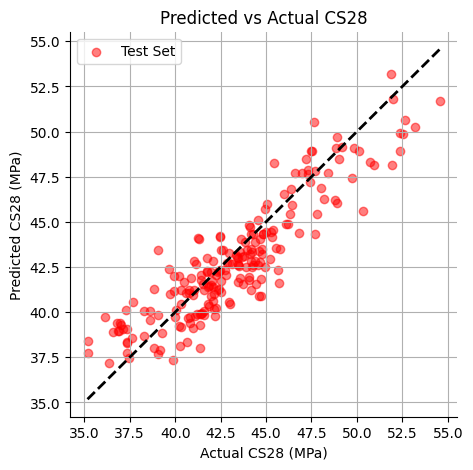

<IPython.core.display.Javascript object>

In [15]:
# Filter to only include the test set
test_data = df_pred[df_pred["SET"] == "TEST"]

# Plot Predicted vs Actual for the test set
plt.figure(figsize=(5.0, 5.0))
plt.scatter(
    test_data["CS28"], test_data["CS28_PRED"], color="red", alpha=0.5, label="Test Set"
)
plt.plot(
    [test_data["CS28"].min(), test_data["CS28"].max()],
    [test_data["CS28"].min(), test_data["CS28"].max()],
    "k--",
    lw=2,
)
plt.xlabel("Actual CS28 (MPa)")
plt.ylabel("Predicted CS28 (MPa)")
plt.title("Predicted vs Actual CS28")
plt.legend()
plt.grid(True)
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.savefig("inn_cm_p_cs_btiss_scpm_top_one_pred_vs_actual_cs28.png", dpi=300, bbox_inches='tight')

plt.show()
# USAR ESSE



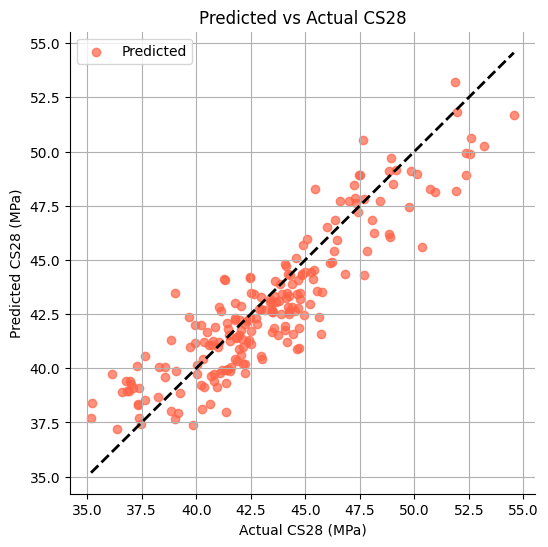

<IPython.core.display.Javascript object>

In [16]:
plt.figure(figsize=(6, 6))
plt.scatter(
    test_data["CS28"],
    test_data["CS28_PRED"],
    color="tomato",
    alpha=0.7,
    label="Predicted",
)
plt.plot(
    [test_data["CS28"].min(), test_data["CS28"].max()],
    [test_data["CS28"].min(), test_data["CS28"].max()],
    color="black",
    linestyle="--",
    linewidth=2,
)
plt.xlabel("Actual CS28 (MPa)")
plt.ylabel("Predicted CS28 (MPa)")
plt.title("Predicted vs Actual CS28")
plt.legend()
plt.grid(True)
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.savefig(
    "inn_cm_p_cs_btiss_scpm_top_one_pred_vs_actual_cs28.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

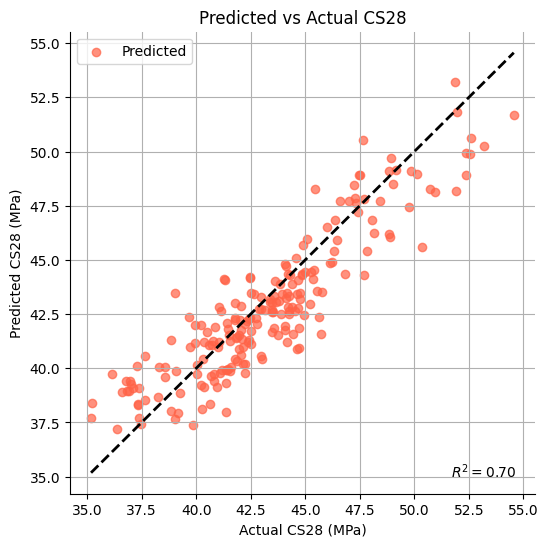

<IPython.core.display.Javascript object>

In [17]:
plt.figure(figsize=(6, 6))
plt.scatter(
    test_data["CS28"],
    test_data["CS28_PRED"],
    color="tomato",
    alpha=0.7,
    label="Predicted",
)
plt.plot(
    [test_data["CS28"].min(), test_data["CS28"].max()],
    [test_data["CS28"].min(), test_data["CS28"].max()],
    color="black",
    linestyle="--",
    linewidth=2,
)
plt.xlabel("Actual CS28 (MPa)")
plt.ylabel("Predicted CS28 (MPa)")
plt.title("Predicted vs Actual CS28")
plt.legend()
plt.grid(True)
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

r2 = 0.70
plt.text(
    0.82,
    0.07,
    f"$R^2 = {r2:.2f}$",
    transform=plt.gca().transAxes,
    verticalalignment="top",
)

plt.savefig(
    "inn_cm_p_cs_btiss_scpm_top_one_pred_vs_actual_cs28.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

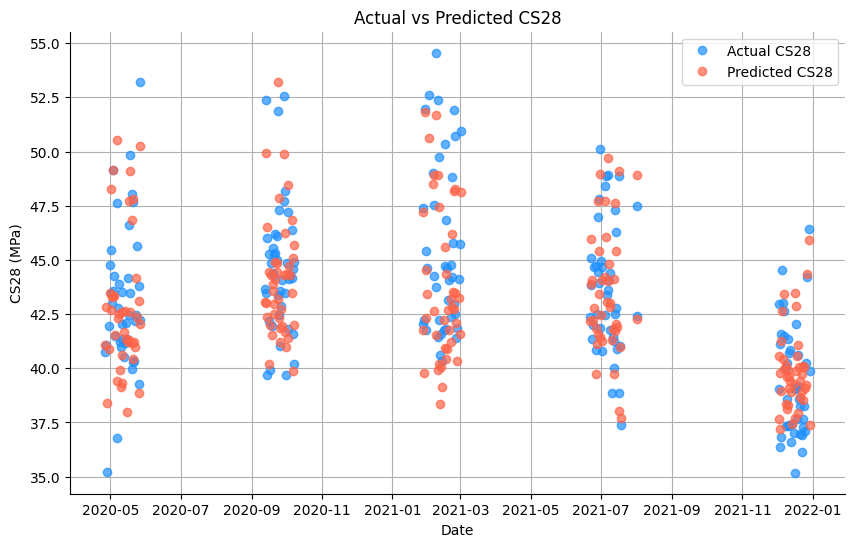

<IPython.core.display.Javascript object>

In [18]:
plt.figure(figsize=(10, 6))
plt.plot(
    test_data["DATE"],
    test_data["CS28"],
    color="dodgerblue",
    alpha=0.7,
    marker="o",
    linestyle="none",
    label="Actual CS28",
)
plt.plot(
    test_data["DATE"],
    test_data["CS28_PRED"],
    color="tomato",
    alpha=0.7,
    marker="o",
    linestyle="none",
    label="Predicted CS28",
)
plt.xlabel("Date")
plt.ylabel("CS28 (MPa)")
plt.title("Actual vs Predicted CS28")
plt.legend()
plt.grid(True)

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.savefig(
    "inn_cm_p_cs_btiss_scpm_top_one_pred_vs_actual_cs28_over_time.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()


## Assessing Feature Importance

In [19]:
df_coefs, df_bias = get_linreg_df_importances(scores)
df_importances = df_coefs

<IPython.core.display.Javascript object>

In [20]:
df_importances

,CaO,SiO2,Al2O3,Fe2O3,MgO,SO3,K2O,Na2O,Total C3S,Total C2S,...,C4AF,Free CaO,Loss on Ignition,Initial setting time,CS1,CS3,CS7,Blaine,Sieve 32 um,Sieve 45 um
Coefficients - 0,0.109881,-0.355210,0.739756,0.025596,-0.110473,-0.085470,-0.528712,0.018012,0.044538,0.401877,...,-0.554900,-0.006473,-0.193287,0.129594,1.474211,1.378331,1.641158,-0.713076,0.371758,0.252273
Coefficients - 1,0.152801,0.102870,-0.035356,0.036366,0.033140,-0.128215,-0.163273,0.005320,0.105330,0.473887,...,-0.330869,-0.511236,-0.079635,-0.461273,0.734143,1.180426,1.895789,-1.123476,-0.109798,-0.509677
Coefficients - 2,0.333281,-0.126544,-0.052987,0.032121,0.232194,0.024147,0.070630,-0.380838,0.956416,1.120957,...,0.544263,0.052393,0.673859,-0.003963,1.570477,1.187408,1.433375,-1.793216,0.070767,0.049585
Coefficients - 3,0.402612,-0.358658,-0.500250,0.104809,-0.225528,-0.263687,-0.092354,-0.240580,1.071154,1.533486,...,0.094190,-0.055255,-0.047890,0.035493,1.213409,1.192481,1.831962,-1.375007,-0.136602,-0.200584
Coefficients - 4,-0.085777,-0.991104,-0.459701,0.333150,-0.327140,-0.165366,-0.656185,-0.121842,0.559048,0.393373,...,-0.118358,0.036011,-1.194704,0.087281,1.275645,1.003298,0.335381,-0.844195,-0.499138,-0.123783


<IPython.core.display.Javascript object>

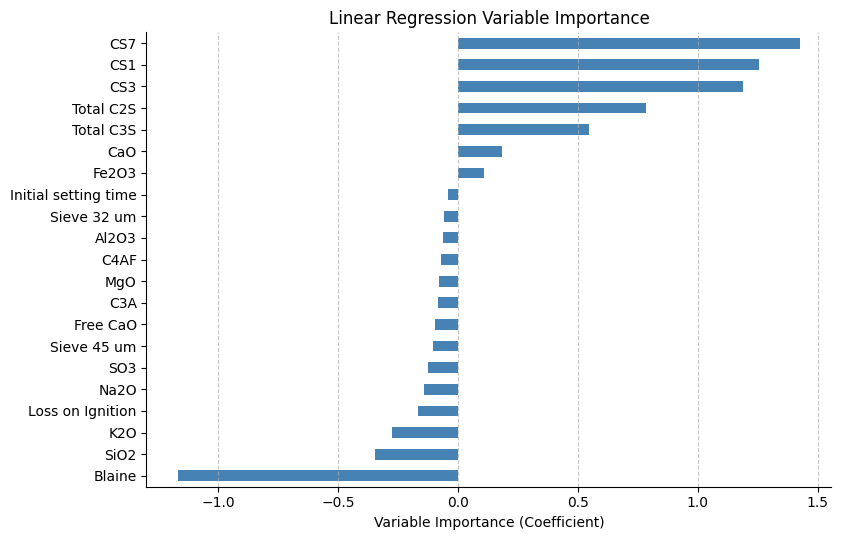

<IPython.core.display.Javascript object>

In [21]:
df_importances.mean(axis=0).sort_values().plot(
    kind="barh", figsize=(10, 5.5), color="steelblue"  # Consider using 'steelblue'
)
plt.title("Linear Regression Variable Importance")
plt.xlabel("Variable Importance (Coefficient)")
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.tight_layout()
plt.subplots_adjust(left=0.3)
plt.show()

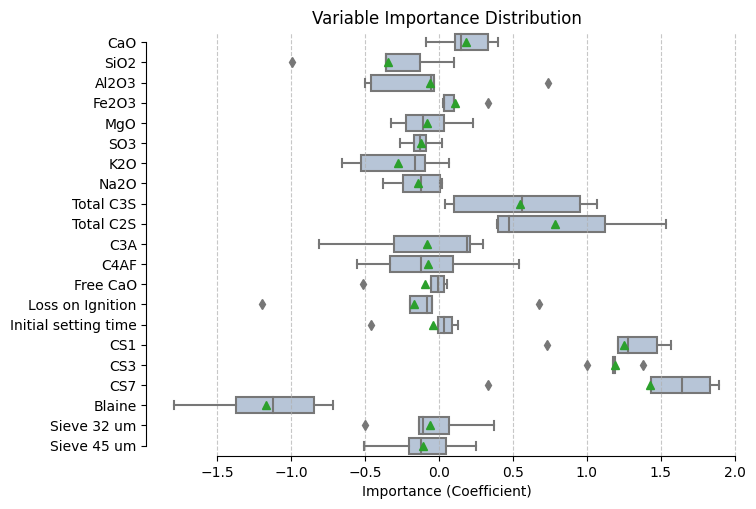

<IPython.core.display.Javascript object>

In [22]:
warnings.filterwarnings("ignore")
plt.figure(figsize=(10, 5.5))
sns.boxplot(
    data=df_importances,
    orient="h",
    color="lightsteelblue",
    saturation=0.7,
    showmeans=True,
)
sns.despine(trim=True, left=False)
plt.xlabel("Importance (Coefficient)")
plt.title("Variable Importance Distribution")
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.subplots_adjust(left=0.3)
plt.show()

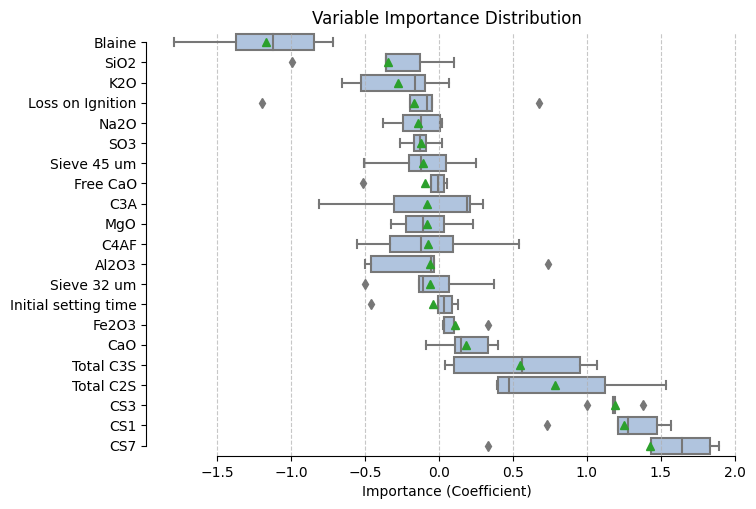

<IPython.core.display.Javascript object>

In [23]:
# Calculate the means of the importance scores
mean_importances = df_importances.mean()

# Sort the features by their mean relevance
sorted_features = mean_importances.sort_values()

# Re-order the DataFrame according to the sorted features
df_importances_sorted = df_importances[sorted_features.index]

# Plot the sorted boxplot
# df_importances_sorted = df_importances_sorted.rename(
#    columns={"Loss on Ignition": "LOI"}
# )

plt.figure(figsize=(10, 5.5))
sns.boxplot(
    data=df_importances_sorted,
    orient="h",
    color="lightsteelblue",
    saturation=1,
    showmeans=True,
)
sns.despine(trim=True, left=False)
plt.xlabel("Importance (Coefficient)")
plt.title("Variable Importance Distribution")
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.subplots_adjust(left=0.3)
plt.savefig(
    "inn_cm_p_cs_btiss_linear_regression_scpm_best_dist_var_relevance.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

In [24]:
print("Default font family:", matplotlib.rcParams["font.family"])
print("Default sans-serif fonts:", matplotlib.rcParams["font.sans-serif"])
print("Default font size:", matplotlib.rcParams["font.size"])
print("Default font weight:", matplotlib.rcParams["font.weight"])

Default font family: ['sans-serif']
Default sans-serif fonts: ['DejaVu Sans', 'Bitstream Vera Sans', 'Computer Modern Sans Serif', 'Lucida Grande', 'Verdana', 'Geneva', 'Lucid', 'Arial', 'Helvetica', 'Avant Garde', 'sans-serif']
Default font size: 10.0
Default font weight: normal


<IPython.core.display.Javascript object>

In [25]:
plt.get_backend()

'module://matplotlib_inline.backend_inline'

<IPython.core.display.Javascript object>

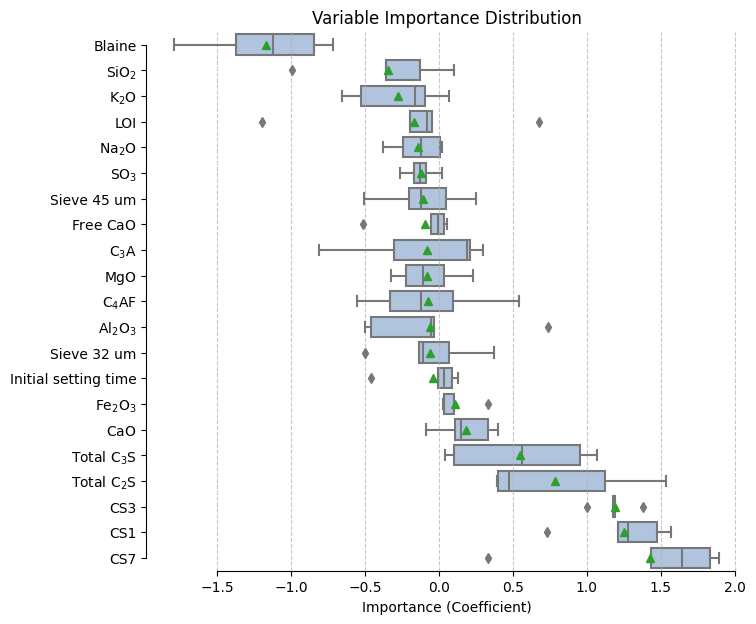

<IPython.core.display.Javascript object>

In [26]:
# Backup the original backend
original_backend = plt.get_backend()

# Use Matplotlib's default backend
# plt.switch_backend("agg")  # or any backend you prefer

# Update font settings to default
plt.rcParams.update(
    {
        "font.family": "sans-serif",
        "font.sans-serif": ["DejaVu Sans"],
        "font.size": 10,
        "text.usetex": False,  # Use MathText, not LaTeX
    }
)


# Convert chemical formulas using MathText syntax
df_importances_sorted_plot = df_importances_sorted.rename(
    columns={
        "Alpha C2S": r"Alpha $\mathrm{C_2S}$",
        "Beta C2S": r"Beta $\mathrm{C_2S}$",
        "Gamma C2S": r"Gamma $\mathrm{C_2S}$",
        "Cubic C3A": r"Cubic $\mathrm{C_3A}$",
        "Orthorhombic C3A": r"Orthorhombic $\mathrm{C_3A}$",
        "K2O": r"$\mathrm{K_2O}$",
        "Free CaO": r"Free $\mathrm{CaO}$",
        "Total C2S": r"Total $\mathrm{C_2S}$",
        "Na2O": r"$\mathrm{Na_2O}$",
        "CaO": r"$\mathrm{CaO}$",
        "SiO2": r"$\mathrm{SiO_2}$",
        "MgO": r"$\mathrm{MgO}$",
        "Fe2O3": r"$\mathrm{Fe_2O_3}$",
        "Al2O3": r"$\mathrm{Al_2O_3}$",
        "Total C3S": r"Total $\mathrm{C_3S}$",
        "C3A": r"$\mathrm{C_3A}$",
        "C4AF": r"$\mathrm{C_4AF}$",
        "LOI": "LOI",
        "SO3": r"$\mathrm{SO_3}$",
        "Insoluble Residue": "IR",
        "Loss on Ignition": "LOI",
    }
)

plt.figure(figsize=(10, 7))
sns.boxplot(
    data=df_importances_sorted_plot,
    orient="h",
    color="lightsteelblue",
    saturation=1,
    showmeans=True,
)
sns.despine(trim=True, left=False)
plt.xlabel("Importance (Coefficient)")
plt.title("Variable Importance Distribution")
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.subplots_adjust(left=0.3)
plt.savefig(
    "inn_cm_p_cs_btiss_linear_regression_scpm_best_dist_var_relevance.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()


# Step 3: Reset all rcParams to their default values
matplotlib.rcParams.update(matplotlib.rcParamsDefault)
plt.rcdefaults()

# Switch back to the original backend
plt.switch_backend(original_backend)

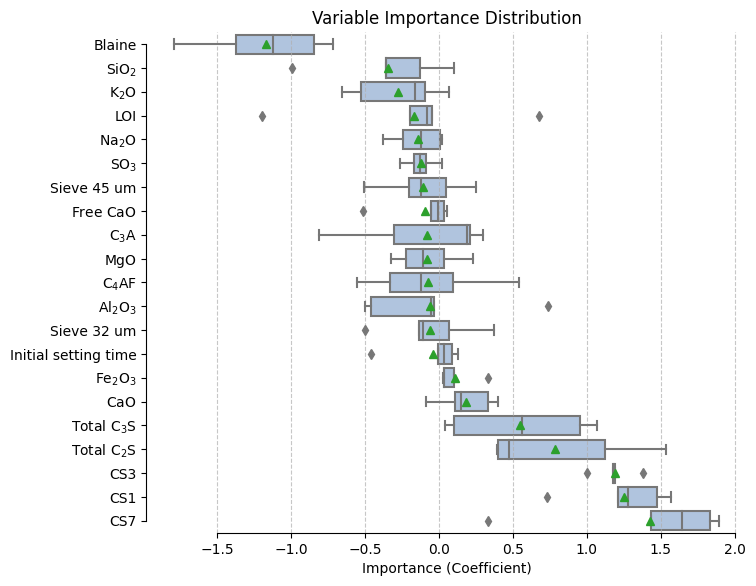

<IPython.core.display.Javascript object>

In [27]:
# Backup the original backend
original_backend = plt.get_backend()

# Use Matplotlib's default backend
# plt.switch_backend("agg")  # or any backend you prefer

# Update font settings to default
plt.rcParams.update(
    {
        "font.family": "sans-serif",
        "font.sans-serif": ["DejaVu Sans"],
        "font.size": 10,
        "text.usetex": False,  # Use MathText, not LaTeX
    }
)


# Convert chemical formulas using MathText syntax
df_importances_sorted_plot = df_importances_sorted.rename(
    columns={
        "Alpha C2S": r"Alpha $\mathrm{C_2S}$",
        "Beta C2S": r"Beta $\mathrm{C_2S}$",
        "Gamma C2S": r"Gamma $\mathrm{C_2S}$",
        "Cubic C3A": r"Cubic $\mathrm{C_3A}$",
        "Orthorhombic C3A": r"Orthorhombic $\mathrm{C_3A}$",
        "K2O": r"$\mathrm{K_2O}$",
        "Free CaO": r"Free $\mathrm{CaO}$",
        "Total C2S": r"Total $\mathrm{C_2S}$",
        "Na2O": r"$\mathrm{Na_2O}$",
        "CaO": r"$\mathrm{CaO}$",
        "SiO2": r"$\mathrm{SiO_2}$",
        "MgO": r"$\mathrm{MgO}$",
        "Fe2O3": r"$\mathrm{Fe_2O_3}$",
        "Al2O3": r"$\mathrm{Al_2O_3}$",
        "Total C3S": r"Total $\mathrm{C_3S}$",
        "C3A": r"$\mathrm{C_3A}$",
        "C4AF": r"$\mathrm{C_4AF}$",
        "LOI": "LOI",
        "SO3": r"$\mathrm{SO_3}$",
        "Insoluble Residue": "IR",
        "Loss on Ignition": "LOI",
    }
)

plt.figure(figsize=(10, 6.5))
sns.boxplot(
    data=df_importances_sorted_plot,
    orient="h",
    color="lightsteelblue",
    saturation=1,
    showmeans=True,
)
sns.despine(trim=True, left=False)
plt.xlabel("Importance (Coefficient)")
plt.title("Variable Importance Distribution")
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.subplots_adjust(left=0.3)

plt.show()


# Step 3: Reset all rcParams to their default values
matplotlib.rcParams.update(matplotlib.rcParamsDefault)
plt.rcdefaults()

# Switch back to the original backend
plt.switch_backend(original_backend)

In [28]:
df_importances

,CaO,SiO2,Al2O3,Fe2O3,MgO,SO3,K2O,Na2O,Total C3S,Total C2S,...,C4AF,Free CaO,Loss on Ignition,Initial setting time,CS1,CS3,CS7,Blaine,Sieve 32 um,Sieve 45 um
Coefficients - 0,0.109881,-0.355210,0.739756,0.025596,-0.110473,-0.085470,-0.528712,0.018012,0.044538,0.401877,...,-0.554900,-0.006473,-0.193287,0.129594,1.474211,1.378331,1.641158,-0.713076,0.371758,0.252273
Coefficients - 1,0.152801,0.102870,-0.035356,0.036366,0.033140,-0.128215,-0.163273,0.005320,0.105330,0.473887,...,-0.330869,-0.511236,-0.079635,-0.461273,0.734143,1.180426,1.895789,-1.123476,-0.109798,-0.509677
Coefficients - 2,0.333281,-0.126544,-0.052987,0.032121,0.232194,0.024147,0.070630,-0.380838,0.956416,1.120957,...,0.544263,0.052393,0.673859,-0.003963,1.570477,1.187408,1.433375,-1.793216,0.070767,0.049585
Coefficients - 3,0.402612,-0.358658,-0.500250,0.104809,-0.225528,-0.263687,-0.092354,-0.240580,1.071154,1.533486,...,0.094190,-0.055255,-0.047890,0.035493,1.213409,1.192481,1.831962,-1.375007,-0.136602,-0.200584
Coefficients - 4,-0.085777,-0.991104,-0.459701,0.333150,-0.327140,-0.165366,-0.656185,-0.121842,0.559048,0.393373,...,-0.118358,0.036011,-1.194704,0.087281,1.275645,1.003298,0.335381,-0.844195,-0.499138,-0.123783


<IPython.core.display.Javascript object>

In [29]:
df_importances.describe().T.sort_values(by=["mean"])

,count,mean,std,min,25%,50%,75%,max
Blaine,5.0,-1.169794,0.432296,-1.793216,-1.375007,-1.123476,-0.844195,-0.713076
SiO2,5.0,-0.345729,0.408059,-0.991104,-0.358658,-0.355210,-0.126544,0.102870
K2O,5.0,-0.273979,0.306174,-0.656185,-0.528712,-0.163273,-0.092354,0.070630
Loss on Ignition,5.0,-0.168331,0.668155,-1.194704,-0.193287,-0.079635,-0.047890,0.673859
Na2O,5.0,-0.143986,0.169156,-0.380838,-0.240580,-0.121842,0.005320,0.018012
SO3,5.0,-0.123718,0.105680,-0.263687,-0.165366,-0.128215,-0.085470,0.024147
Sieve 45 um,5.0,-0.106437,0.284949,-0.509677,-0.200584,-0.123783,0.049585,0.252273
Free CaO,5.0,-0.096912,0.235340,-0.511236,-0.055255,-0.006473,0.036011,0.052393
C3A,5.0,-0.082290,0.471015,-0.809948,-0.305585,0.190832,0.213310,0.299939
MgO,5.0,-0.079561,0.219915,-0.327140,-0.225528,-0.110473,0.033140,0.232194


<IPython.core.display.Javascript object>

In [30]:
df_importances.mean(axis=0)

CaO                     0.182560
SiO2                   -0.345729
Al2O3                  -0.061708
Fe2O3                   0.106408
MgO                    -0.079561
SO3                    -0.123718
K2O                    -0.273979
Na2O                   -0.143986
Total C3S               0.547297
Total C2S               0.784716
C3A                    -0.082290
C4AF                   -0.073135
Free CaO               -0.096912
Loss on Ignition       -0.168331
Initial setting time   -0.042574
CS1                     1.253577
CS3                     1.188389
CS7                     1.427533
Blaine                 -1.169794
Sieve 32 um            -0.060603
Sieve 45 um            -0.106437
dtype: float64

<IPython.core.display.Javascript object>

In [31]:
from sklearn.inspection import permutation_importance

<IPython.core.display.Javascript object>

In [32]:
# Initialize lists to store importance results
mdi_importances = []
perm_importances = []

# Compute feature importances
for i, (train_idx, test_idx) in enumerate(cv.split(x, y)):
    pipeline.fit(x.iloc[train_idx], y[train_idx])

    # Extract the trained model
    model = pipeline.named_steps["estimator"]
    imputer = pipeline.named_steps["imputer"]
    scaler = pipeline.named_steps["transformer"]
    # Compute MDI importance
    # mdi_importances.append(model.feature_importances_)

    # Compute permutation importance
    result = permutation_importance(
        model,
        scaler.transform(imputer.transform(x.iloc[test_idx])),
        y[test_idx],
        n_repeats=10,
        random_state=SEED,
        n_jobs=-1,
        # scoring="neg_mean_squared_error",
        scoring="r2",
    )
    perm_importances.append(result.importances_mean)

<IPython.core.display.Javascript object>

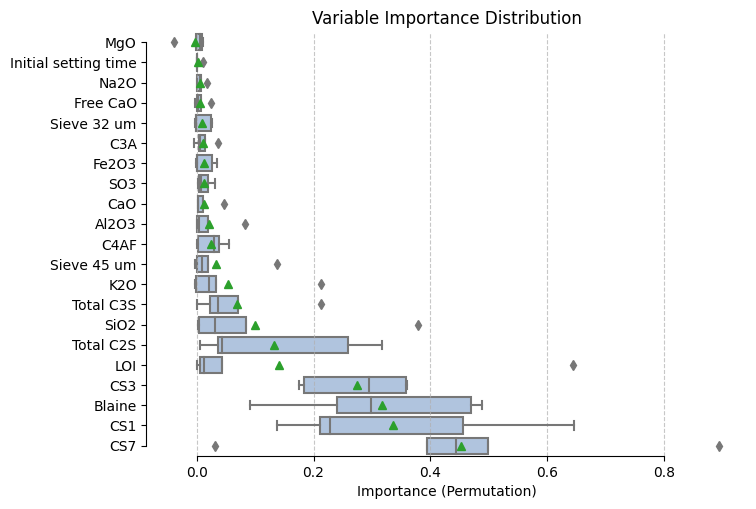

<IPython.core.display.Javascript object>

In [33]:
# Convert lists to DataFrames
# mdi_importances_df = pd.DataFrame(mdi_importances, columns=x.columns)
perm_importances_df = pd.DataFrame(perm_importances, columns=x.columns)


# Calculate the mean importance for each feature
mean_importances = perm_importances_df.mean().sort_values()

# Reorder the DataFrame columns based on mean importance
perm_importances_df = perm_importances_df[mean_importances.index]

perm_importances_df = perm_importances_df.rename(
    columns={"Loss on Ignition": "LOI", "Insoluble Residue": "IR"}
)


plt.figure(figsize=(10, 5.5))
sns.boxplot(
    data=perm_importances_df,
    orient="h",
    color="lightsteelblue",
    saturation=1,
    showmeans=True,
)
sns.despine(trim=True, left=False)
plt.xlabel("Importance (Permutation)")
plt.title("Variable Importance Distribution")
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.subplots_adjust(left=0.3)
plt.savefig(
    "inn_cm_p_cs_btiss_linear_regression_scpm_best_dist_var_perm_relevance.png",
    dpi=300,
    bbox_inches="tight",
)

# # Step 3: Reset all rcParams to their default values
plt.rcdefaults()

plt.show()

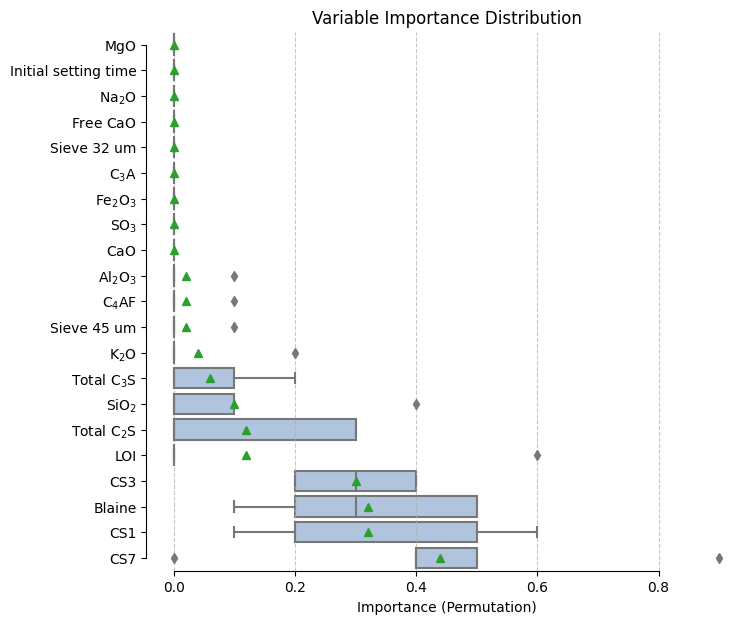

<IPython.core.display.Javascript object>

In [34]:
# Backup the original backend
original_backend = plt.get_backend()

# Use Matplotlib's default backend
# plt.switch_backend("agg")  # or any backend you prefer

# Update font settings to default
plt.rcParams.update(
    {
        "font.family": "sans-serif",
        "font.sans-serif": ["DejaVu Sans"],
        "font.size": 10,
        "text.usetex": False,  # Use MathText, not LaTeX
    }
)


# Convert chemical formulas using MathText syntax
perm_importances_df_plot = perm_importances_df.rename(
    columns={
        "Alpha C2S": r"Alpha $\mathrm{C_2S}$",
        "Beta C2S": r"Beta $\mathrm{C_2S}$",
        "Gamma C2S": r"Gamma $\mathrm{C_2S}$",
        "Cubic C3A": r"Cubic $\mathrm{C_3A}$",
        "Orthorhombic C3A": r"Orthorhombic $\mathrm{C_3A}$",
        "K2O": r"$\mathrm{K_2O}$",
        "Free CaO": r"Free $\mathrm{CaO}$",
        "Total C2S": r"Total $\mathrm{C_2S}$",
        "Na2O": r"$\mathrm{Na_2O}$",
        "CaO": r"$\mathrm{CaO}$",
        "SiO2": r"$\mathrm{SiO_2}$",
        "MgO": r"$\mathrm{MgO}$",
        "Fe2O3": r"$\mathrm{Fe_2O_3}$",
        "Al2O3": r"$\mathrm{Al_2O_3}$",
        "Total C3S": r"Total $\mathrm{C_3S}$",
        "C3A": r"$\mathrm{C_3A}$",
        "C4AF": r"$\mathrm{C_4AF}$",
        "LOI": "LOI",
        "SO3": r"$\mathrm{SO_3}$",
        "Insoluble Residue": "IR",
        "Loss on Ignition": "LOI",
    }
)

plt.figure(figsize=(10, 7))
sns.boxplot(
    data=perm_importances_df_plot.round(1),
    orient="h",
    color="lightsteelblue",
    saturation=1,
    showmeans=True,
)
sns.despine(trim=True, left=False)
plt.xlabel("Importance (Permutation)")
plt.title("Variable Importance Distribution")
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.subplots_adjust(left=0.3)
plt.savefig(
    "inn_cm_p_cs_btiss_linear_regression_scpm_best_dist_var_perm_relevance.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

# Step 3: Reset all rcParams to their default values
matplotlib.rcParams.update(matplotlib.rcParamsDefault)
plt.rcdefaults()

# Switch back to the original backend
plt.switch_backend(original_backend)

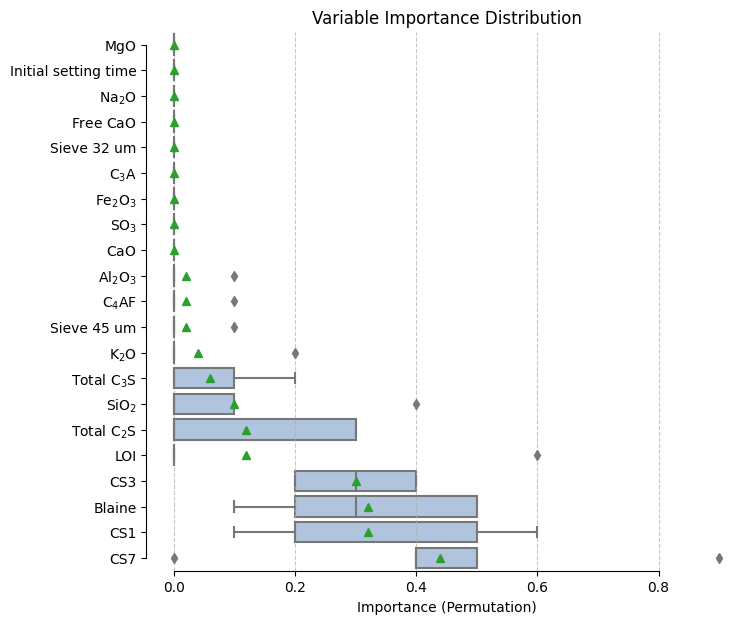

<IPython.core.display.Javascript object>

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

# Backup the original backend
original_backend = plt.get_backend()

# Update font settings to default
plt.rcParams.update(
    {
        "font.family": "sans-serif",
        "font.sans-serif": ["DejaVu Sans"],
        "font.size": 10,
        "text.usetex": False,  # Use MathText, not LaTeX
    }
)

# Convert chemical formulas using MathText syntax
perm_importances_df_plot = perm_importances_df.rename(
    columns={
        "Alpha C2S": r"Alpha $\mathrm{C_2S}$",
        "Beta C2S": r"Beta $\mathrm{C_2S}$",
        "Gamma C2S": r"Gamma $\mathrm{C_2S}$",
        "Cubic C3A": r"Cubic $\mathrm{C_3A}$",
        "Orthorhombic C3A": r"Orthorhombic $\mathrm{C_3A}$",
        "K2O": r"$\mathrm{K_2O}$",
        "Free CaO": r"Free $\mathrm{CaO}$",
        "Total C2S": r"Total $\mathrm{C_2S}$",
        "Na2O": r"$\mathrm{Na_2O}$",
        "CaO": r"$\mathrm{CaO}$",
        "SiO2": r"$\mathrm{SiO_2}$",
        "MgO": r"$\mathrm{MgO}$",
        "Fe2O3": r"$\mathrm{Fe_2O_3}$",
        "Al2O3": r"$\mathrm{Al_2O_3}$",
        "Total C3S": r"Total $\mathrm{C_3S}$",
        "C3A": r"$\mathrm{C_3A}$",
        "C4AF": r"$\mathrm{C_4AF}$",
        "LOI": "LOI",
        "SO3": r"$\mathrm{SO_3}$",
        "Insoluble Residue": "IR",
        "Loss on Ignition": "LOI",
    }
)

plt.figure(figsize=(10, 7))

# Create boxplot
sns.boxplot(
    data=perm_importances_df_plot.round(1),
    orient="h",
    color="lightsteelblue",
    saturation=1,
    showmeans=True,
)
sns.despine(trim=True, left=False)

# Set x-axis label and title
plt.xlabel("Importance (Permutation)")
plt.title("Variable Importance Distribution")

# Add gridlines for x-axis
plt.grid(axis="x", linestyle="--", alpha=0.7)

# Format x-axis to show 1 decimal place
plt.gca().xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x:.1f}"))

# Adjust the layout to prevent label cut-off
plt.subplots_adjust(left=0.3)

# Save the plot
plt.savefig(
    "inn_cm_p_cs_btiss_linear_regression_scpm_best_dist_var_perm_relevance.png",
    dpi=300,
    bbox_inches="tight",
)

# Show the plot
plt.show()

# Reset all rcParams to their default values
plt.rcdefaults()

# Switch back to the original backend
plt.switch_backend(original_backend)

In [36]:
perm_importances_df.describe().round(4).T.sort_values(by="mean")

,count,mean,std,min,25%,50%,75%,max
MgO,5.0,-0.0029,0.0209,-0.0394,-0.0007,0.0054,0.0092,0.0111
Initial setting time,5.0,0.0022,0.0043,-0.0004,0.0001,0.0006,0.0009,0.0099
Na2O,5.0,0.0059,0.0071,-0.0003,0.0001,0.0060,0.0066,0.0172
Free CaO,5.0,0.0063,0.0110,-0.0024,0.0002,0.0015,0.0072,0.0249
Sieve 32 um,5.0,0.0089,0.0145,-0.0025,-0.0013,-0.0012,0.0238,0.0255
C3A,5.0,0.0108,0.0157,-0.0055,0.0037,0.0059,0.0139,0.0359
Fe2O3,5.0,0.0118,0.0170,-0.0012,-0.0004,0.0003,0.0258,0.0343
SO3,5.0,0.0124,0.0122,0.0014,0.0041,0.0068,0.0194,0.0305
CaO,5.0,0.0128,0.0189,0.0023,0.0023,0.0026,0.0106,0.0460
Al2O3,5.0,0.0211,0.0349,0.0004,0.0007,0.0038,0.0185,0.0821


<IPython.core.display.Javascript object>

In [37]:
perm_importances_df

,MgO,Initial setting time,Na2O,Free CaO,Sieve 32 um,C3A,Fe2O3,SO3,CaO,Al2O3,...,Sieve 45 um,K2O,Total C3S,SiO2,Total C2S,LOI,CS3,Blaine,CS1,CS7
0,0.005365,-0.000360,-0.000275,0.000153,0.023833,0.035910,-0.001227,0.004125,0.010621,0.018500,...,-0.003465,0.033084,-0.000292,0.084877,0.005246,0.013099,0.183778,0.090310,0.210325,0.394363
1,-0.000669,0.009853,0.000054,0.024921,-0.001319,0.005881,-0.000351,0.006756,0.002296,0.000400,...,0.136908,-0.002329,0.023215,0.003010,0.035943,0.004787,0.360136,0.298160,0.137153,0.894649
2,0.009245,0.000098,0.006631,0.007162,-0.001199,0.013874,0.000324,0.001423,0.002626,0.000731,...,0.000376,-0.000609,0.212603,0.002257,0.259438,0.042727,0.358129,0.488171,0.646004,0.443523
3,0.011145,0.000569,0.005988,0.001547,-0.002529,-0.005488,0.025848,0.030467,0.045974,0.082079,...,0.019652,0.021396,0.071279,0.030780,0.316910,0.000715,0.294660,0.469048,0.228834,0.498581
4,-0.039421,0.000913,0.017157,-0.002389,0.025510,0.003669,0.034297,0.019385,0.002321,0.003794,...,0.008743,0.212457,0.036379,0.378755,0.042421,0.645033,0.174624,0.240511,0.455830,0.031626


<IPython.core.display.Javascript object>

In [38]:
perm_importances_df.mean(axis=0)

MgO                    -0.002867
Initial setting time    0.002215
Na2O                    0.005911
Free CaO                0.006279
Sieve 32 um             0.008859
C3A                     0.010770
Fe2O3                   0.011778
SO3                     0.012431
CaO                     0.012768
Al2O3                   0.021101
C4AF                    0.024799
Sieve 45 um             0.032443
K2O                     0.052800
Total C3S               0.068637
SiO2                    0.099936
Total C2S               0.131991
LOI                     0.141272
CS3                     0.274265
Blaine                  0.317240
CS1                     0.335629
CS7                     0.452549
dtype: float64

<IPython.core.display.Javascript object>

In [39]:
perm_importances_df.std(axis=0, ddof=0)

MgO                     0.018718
Initial setting time    0.003843
Na2O                    0.006318
Free CaO                0.009832
Sieve 32 um             0.012930
C3A                     0.014002
Fe2O3                   0.015182
SO3                     0.010918
CaO                     0.016905
Al2O3                   0.031203
C4AF                    0.021387
Sieve 45 um             0.052831
K2O                     0.080941
Total C3S               0.075615
SiO2                    0.142608
Total C2S               0.129422
LOI                     0.252309
CS3                     0.081165
Blaine                  0.148332
CS1                     0.188298
CS7                     0.275033
dtype: float64

<IPython.core.display.Javascript object>

In [40]:
# np.std(y)
len(y)
plt.rcdefaults()

# Switch back to the original backend
plt.switch_backend(original_backend)
df["CS28"].describe().T

count    1053.000000
mean       43.000541
std         3.530197
min        34.150000
25%        40.660000
50%        42.490000
75%        45.050000
max        54.560000
Name: CS28, dtype: float64

<IPython.core.display.Javascript object>